In [1]:
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ultranest
from ultranest.plot import PredictionBand, cornerplot
import george
# save results to file
import pickle
from pathlib import Path

In [2]:
urllib.request.urlretrieve(
    "https://berkeley-earth-temperature.s3.us-west-1.amazonaws.com/Global/Land_and_Ocean_summary.txt",
    "Land_and_Ocean_complete_annual.txt"
)
data = np.loadtxt("Land_and_Ocean_complete_annual.txt", comments="%")
columns = [
    "year",
    "annual_anomaly_above", "annual_unc_above",
    "five_year_anomaly_above", "five_year_unc_above",
    "annual_anomaly_below", "annual_unc_below",
    "five_year_anomaly_below", "five_year_unc_below",
]

df = pd.DataFrame(data, columns=columns)

dtype_map = {
    "year": "int",
    "annual_anomaly_above": "float",
    "annual_unc_above": "float",
    "five_year_anomaly_above": "float",
    "five_year_unc_above": "float",
    "annual_anomaly_below": "float",
    "annual_unc_below": "float",
    "five_year_anomaly_below": "float",
    "five_year_unc_below": "float",
}
df = df.astype(dtype_map)

yerr_above = df["annual_unc_above"] / 1.96
yerr_below = df["annual_unc_below"] / 1.96

date = df["year"].values
temp_anomaly = df["annual_anomaly_above"].values
sigma2 = yerr_above ** 2

## Gaussian Processes


In [3]:
# gaussian process model used in every regression (with/whithout trends)
def gp_model(amplitude, length_scale, yerr):
    kernel = amplitude**2 * george.kernels.ExpSquaredKernel(length_scale**2, axes=0)
    gp = george.GP(kernel)
    gp.compute(date.astype(float), yerr)
    return gp


In [5]:
# no trend

def gp_prior(cube):
    params = cube.copy()

    lo_0 = 0.0
    hi_0 = 5.0
    params[0] = lo_0 + cube[0] * (hi_0 - lo_0)

    lo_1 = 0.0
    hi_1 = 100.0
    params[1] = lo_1 + cube[1] * (hi_1 - lo_1)

    return params

def log_gp_likelihood(params):
    amp, length = params

    if amp <= 0 or length <= 0:
        return -1e300

    gp = gp_model(amplitude=amp, length_scale=length, yerr=yerr_above.to_numpy())
    log_likelihood_value = gp.log_likelihood(temp_anomaly, quiet=True)

    if not np.isfinite(log_likelihood_value):
        return -1e300

    return log_likelihood_value


parameters_gp = ["amplitude", "length_scale"]

In [6]:
sampler_gp = ultranest.ReactiveNestedSampler(parameters_gp, log_gp_likelihood, gp_prior)
result_gp = sampler_gp.run(min_ess=1000)
print(result_gp)

[ultranest] Sampling 400 live points from prior ...


[ultranest] Explored until L=2e+01  21.8079..21.8079]*| it/evals=6570/9082 eff=75.6738% N=400          0  
[ultranest] Likelihood function evaluations: 9092
[ultranest]   logZ = 10 +- 0.107
[ultranest] Effective samples strategy satisfied (ESS = 1579.5, need >1000)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.06 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.11, need <0.5)
[ultranest]   logZ error budget: single: 0.16 bs:0.11 tail:0.01 total:0.11 required:<0.50
[ultranest] done iterating.
{'niter': 6978, 'logz': np.float64(9.975919742566568), 'logzerr': np.float64(0.2361222411039094), 'logz_bs': np.float64(10.000866483193022), 'logz_single': np.float64(9.975919742566568), 'logzerr_tail': np.float64(0.00994108452285225), 'logzerr_bs': np.float64(0.2359128813406386), 'ess': np.float64(1579.4890883964983), 'H': np.float64(10.845920203618547), 'Herr': np.float64(0.10102703841416943), 'posterior': {'mean': [0.3354444338198394, 1.

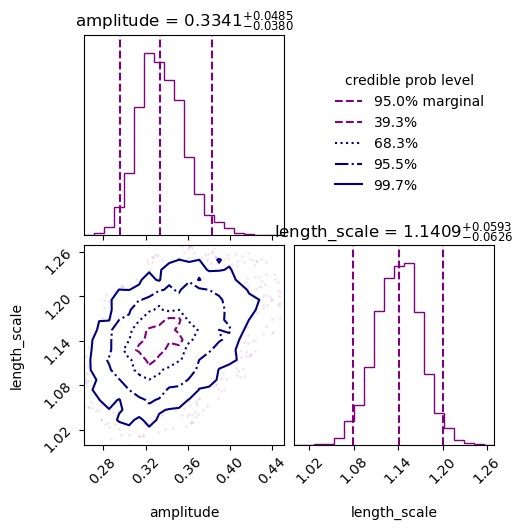

In [7]:
cornerplot(
    result_gp,
    title_fmt=".4f",
    #plot_density=True,
    plot_datapoints=True,
    plot_contours=True,
    use_math_text=True,
    quantiles=[0.025, 0.5, 0.975],
    smooth=False
)
plt.show()
#print(np.exp(result_gp["samples"][0][0]), np.exp(result_gp["samples"][0][1]))

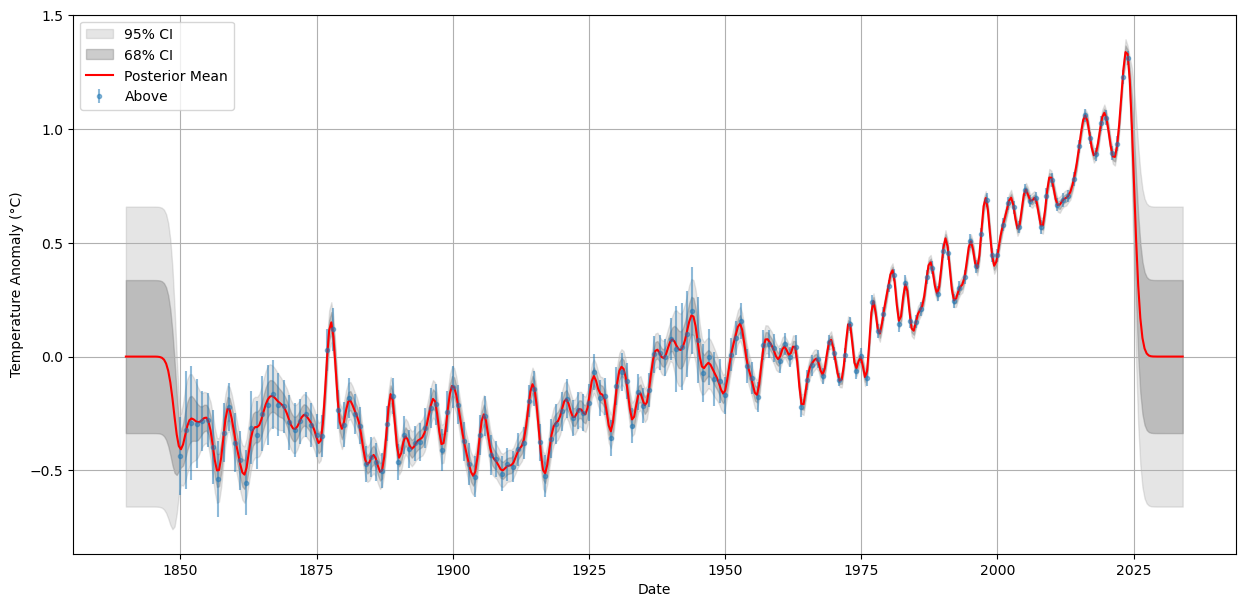

In [8]:
plt.figure(figsize=(15, 7))
plt.errorbar(df["year"], df["annual_anomaly_above"], yerr=df["annual_unc_above"], fmt="o", markersize=3, label="Above", alpha=0.5)

year_range = np.linspace(df["year"].min()-10, df["year"].max()+10, 500)
yerr = yerr_above.to_numpy()

# Collect predictions and variances from all posterior samples
means = []
variances = []
for params in result_gp["samples"]:
    amp, length = params
    gp = gp_model(amplitude=amp, length_scale=length, yerr=yerr)
    mu, var = gp.predict(temp_anomaly, year_range.astype(float), return_var=True)
    means.append(mu)
    variances.append(var)

means = np.array(means)
variances = np.array(variances)

# Combine across posterior samples using law of total variance
# E[Y] = mean of posterior means, Var[Y] = E[Var[Y|θ]] + Var[E[Y|θ]]
mean_pred = np.mean(means, axis=0)
var_pred = np.mean(variances, axis=0) + np.var(means, axis=0)
std_pred = np.sqrt(var_pred)

# Plot confidence intervals
plt.fill_between(year_range, mean_pred - 1.96*std_pred, mean_pred + 1.96*std_pred, color="gray", alpha=0.2, label="95% CI")
plt.fill_between(year_range, mean_pred - 1.0*std_pred, mean_pred + 1.0*std_pred, color="gray", alpha=0.4, label="68% CI")
plt.plot(year_range, mean_pred, color="red", linewidth=1.5, label="Posterior Mean")

plt.xlabel("Date")
plt.ylabel("Temperature Anomaly (°C)")
plt.grid()
plt.legend()

plt.show()

In [9]:
def linear_trend(x, intercept, slope):
    return intercept + slope * x

def gp_linear_prior(cube):
    params = np.empty_like(cube)
    
    lo_0 = -2000.0
    hi_0 = 2000.0
    params[0] = lo_0 + cube[0] * (hi_0 - lo_0)

    lo_1 = -5.
    hi_1 = 5.
    params[1] = lo_1 + cube[1] * (hi_1 - lo_1)

    lo_2 = 1e-3
    hi_2 = 10.0
    params[2] = lo_2 + cube[2] * (hi_2 - lo_2)

    lo_3 = 1e-5
    hi_3 = 200.0
    params[3] = lo_3 + cube[3] * (hi_3 - lo_3)

    return params

def log_gp_likelihood(params):
    intercept, slope, amp, length = params

    if amp <= 0 or length <= 0:
        return -1e300

    trend = linear_trend(date, intercept, slope)
    gp = gp_model(amplitude=amp, length_scale=length, yerr=yerr_above.to_numpy())
    log_likelihood_value = gp.log_likelihood(temp_anomaly - trend, quiet=True)

    if not np.isfinite(log_likelihood_value):
        return -1e300

    return log_likelihood_value

parameters_linear_gp = ["trend_intercept", "trend_slope", "amplitude", "length_scale"]

In [10]:
sampler_linear_gp = ultranest.ReactiveNestedSampler(parameters_linear_gp, log_gp_likelihood, gp_linear_prior)
result_linear_gp = sampler_linear_gp.run()
print(result_linear_gp)

[ultranest] Sampling 400 live points from prior ...


[ultranest] Explored until L=9e+01  86.7534..86.7535]*| it/evals=15430/50345 eff=30.8940% N=400             0  00 0  
[ultranest] Likelihood function evaluations: 50363
[ultranest]   logZ = 52.85 +- 0.2199
[ultranest] Effective samples strategy satisfied (ESS = 2144.9, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.06 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.22, need <0.5)
[ultranest]   logZ error budget: single: 0.28 bs:0.22 tail:0.01 total:0.22 required:<0.50
[ultranest] done iterating.
{'niter': 15839, 'logz': np.float64(52.812014786441885), 'logzerr': np.float64(0.39072553409921906), 'logz_bs': np.float64(52.849704932226274), 'logz_single': np.float64(52.812014786441885), 'logzerr_tail': np.float64(0.009944148653552531), 'logzerr_bs': np.float64(0.3905989719708387), 'ess': np.float64(2144.9013498400886), 'H': np.float64(32.02762917666301), 'Herr': np.float64(0.21339204434272238), 'posterior': {'mean': [-13

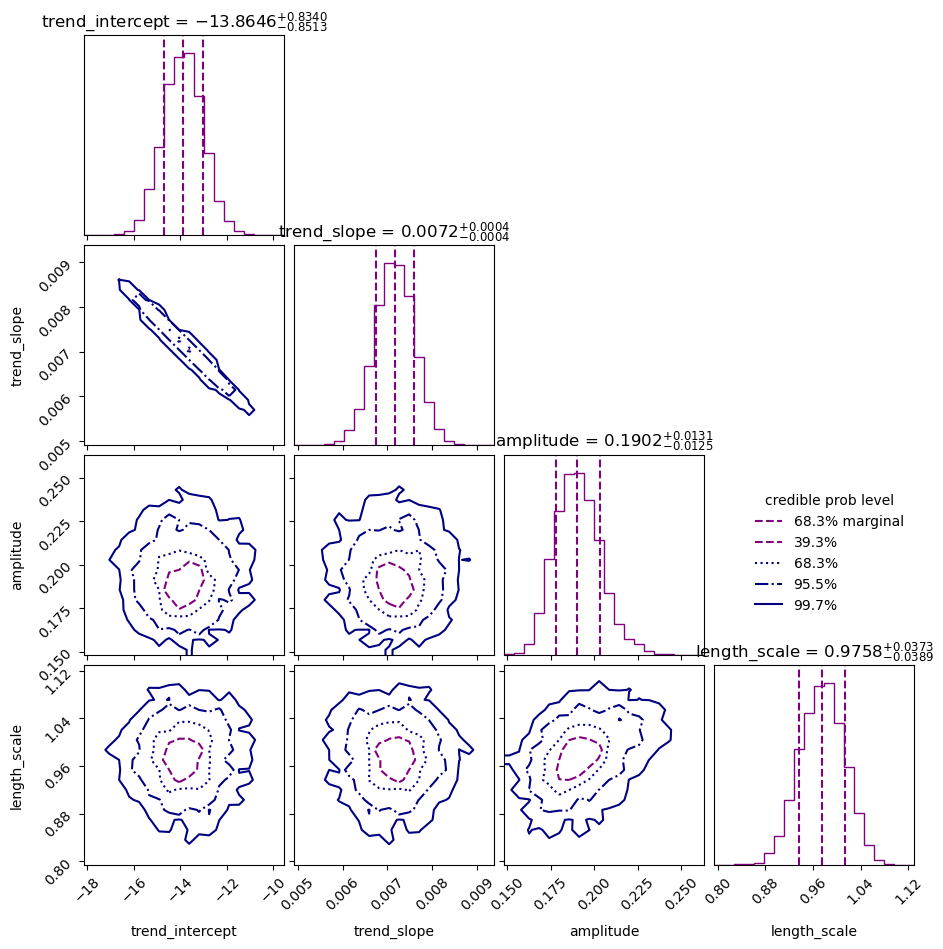

In [11]:
cornerplot(
    result_linear_gp,
    title_fmt=".4f",
    #quantiles=[0.025, 0.5, 0.975]
)
plt.show()

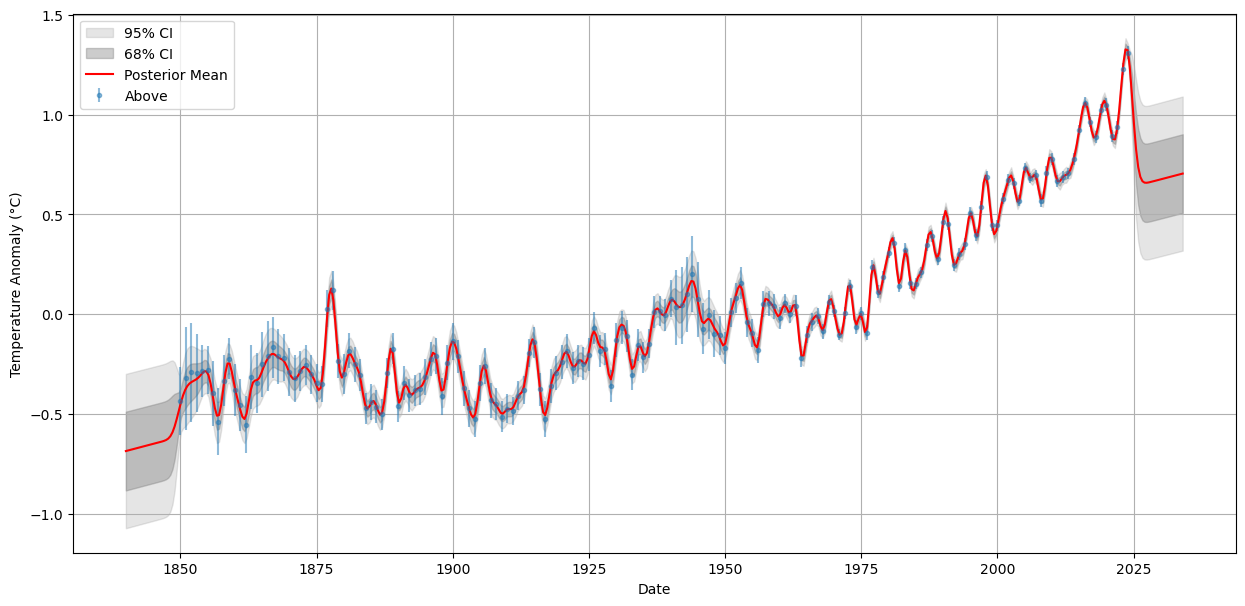

In [12]:
plt.figure(figsize=(15, 7))
plt.errorbar(df["year"], df["annual_anomaly_above"], yerr=df["annual_unc_above"], fmt="o", markersize=3, label="Above", alpha=0.5)

year_range = np.linspace(df["year"].min() - 10, df["year"].max() + 10, 500)
yerr = yerr_above.to_numpy()

# Collect predictions and variances from all posterior samples
means = []
variances = []
for params in result_linear_gp["samples"]:
    intercept, slope, amp, length = params
    gp = gp_model(amplitude=amp, length_scale=length, yerr=yerr)
    trend_obs = linear_trend(date, intercept, slope)
    trend_pred = linear_trend(year_range, intercept, slope)
    mu, var = gp.predict(temp_anomaly - trend_obs, year_range.astype(float), return_var=True)
    means.append(mu + trend_pred)
    variances.append(var)

means = np.array(means)
variances = np.array(variances)

# Combine across posterior samples using law of total variance
mean_pred = np.mean(means, axis=0)
var_pred = np.mean(variances, axis=0) + np.var(means, axis=0)
std_pred = np.sqrt(var_pred)

# Plot confidence intervals
plt.fill_between(year_range, mean_pred - 1.96*std_pred, mean_pred + 1.96*std_pred, color="gray", alpha=0.2, label="95% CI")
plt.fill_between(year_range, mean_pred - 1.0*std_pred, mean_pred + 1.0*std_pred, color="gray", alpha=0.4, label="68% CI")
plt.plot(year_range, mean_pred, color="red", linewidth=1.5, label="Posterior Mean")

plt.xlabel("Date")
plt.ylabel("Temperature Anomaly (°C)")
plt.grid()
plt.legend()

plt.show()

In [13]:
def exponential_trend(x, q, a, m):
    t = (np.asarray(x) - 1950.0) / 50.0
    return q + a * np.exp(m * t)

def gp_exp_prior(cube):
    params = cube.copy()

    lo_0 = -2.0
    hi_0 = 2.0
    params[0] = lo_0 + cube[0] * (hi_0 - lo_0)

    lo_1 = -2.0
    hi_1 = 2.0
    params[1] = lo_1 + cube[1] * (hi_1 - lo_1)

    lo_2 = -4.0
    hi_2 = 4.0
    params[2] = lo_2 + cube[2] * (hi_2 - lo_2)

    lo_3 = 1e-3
    hi_3 = 10.0
    params[3] = lo_3 + cube[3] * (hi_3 - lo_3)

    lo_4 = 1e-5
    hi_4 = 200.0
    params[4] = lo_4 + cube[4] * (hi_4 - lo_4)

    return params

def log_exp_gp_likelihood(params):
    q, a, m, amp, length = params

    if amp <= 0 or length <= 0:
        return -1e300

    trend = exponential_trend(date, q, a, m)
    gp = gp_model(amplitude=amp, length_scale=length, yerr=yerr_above.to_numpy())
    log_likelihood_value = gp.log_likelihood(temp_anomaly - trend, quiet=True)

    if not np.isfinite(log_likelihood_value):
        return -1e300

    return log_likelihood_value

parameters_exp_gp = ["trend_q", "trend_a", "trend_m", "amplitude", "length_scale"]

In [14]:
sampler_exp_gp = ultranest.ReactiveNestedSampler(parameters_exp_gp, log_exp_gp_likelihood, gp_exp_prior)
result_exp_gp = sampler_exp_gp.run()
print(result_exp_gp)

[ultranest] Sampling 400 live points from prior ...


[ultranest] Explored until L=1e+02  3 [140.1959..140.1963]*| it/evals=12800/201855 eff=6.3538% N=400    0  
[ultranest] Likelihood function evaluations: 201924
[ultranest]   logZ = 112.9 +- 0.1687
[ultranest] Effective samples strategy satisfied (ESS = 2375.6, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.45+-0.06 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy wants 398 minimum live points (dlogz from 0.13 to 0.54, need <0.5)
[ultranest]   logZ error budget: single: 0.25 bs:0.17 tail:0.01 total:0.17 required:<0.50
[ultranest] done iterating.
{'niter': 13223, 'logz': np.float64(112.83413964218215), 'logzerr': np.float64(0.5435532476245267), 'logz_bs': np.float64(112.86412617711107), 'logz_single': np.float64(112.83413964218215), 'logzerr_tail': np.float64(0.009936509511959457), 'logzerr_bs': np.float64(0.5434624170831768), 'ess': np.float64(2375.5677599859796), 'H': np.float64(25.092517430501346), 'Herr': np.float64(0.1651117243661497), 'poste

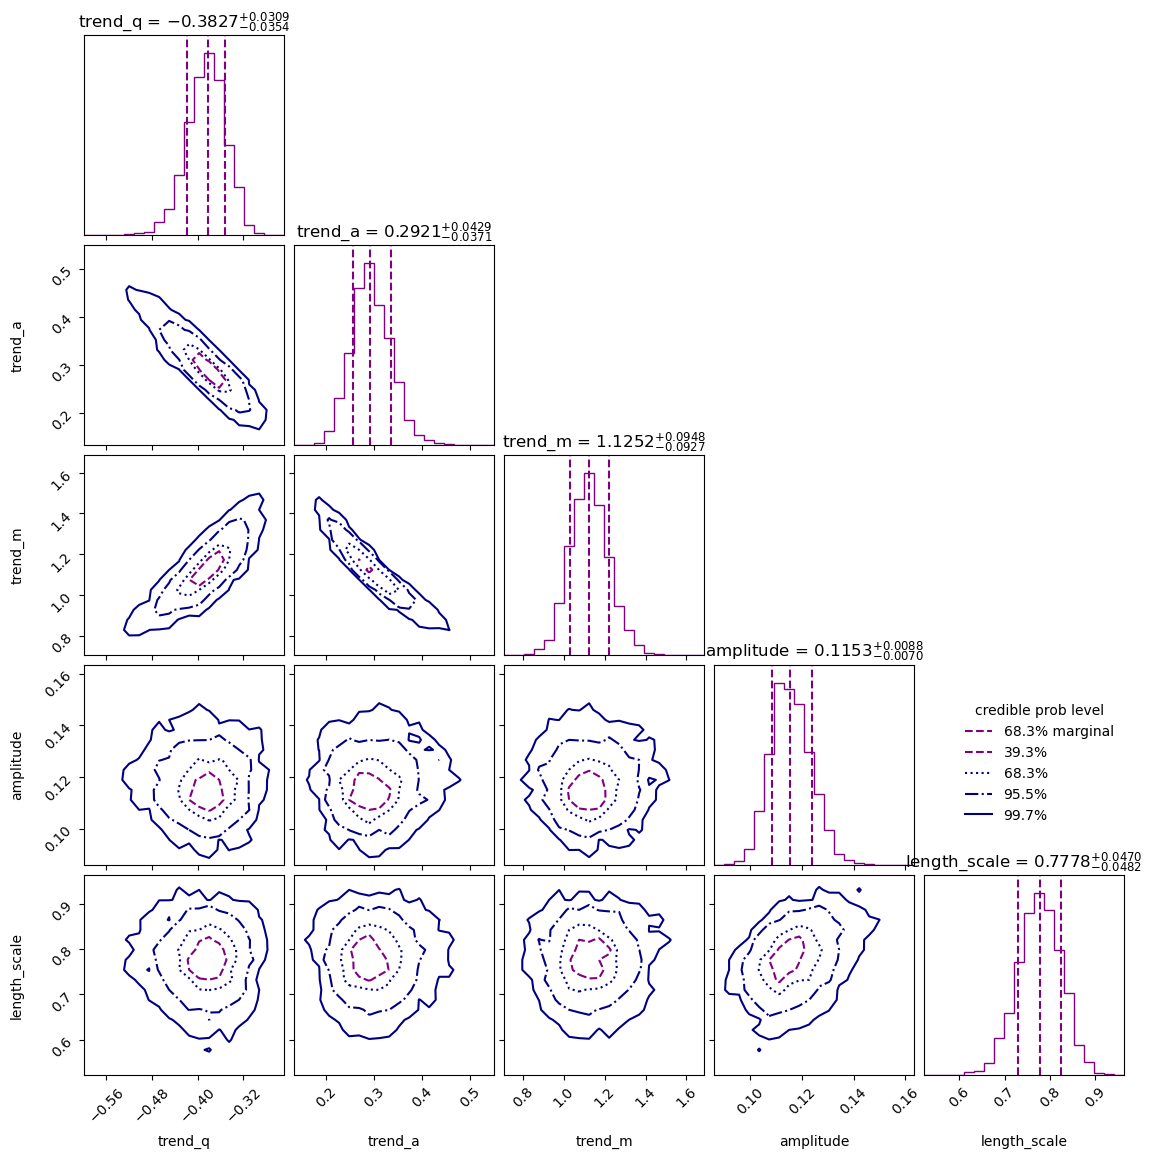

In [15]:
cornerplot(
    result_exp_gp,
    title_fmt=".4f",
    #quantiles=[0.025, 0.5, 0.975]
)
plt.show()

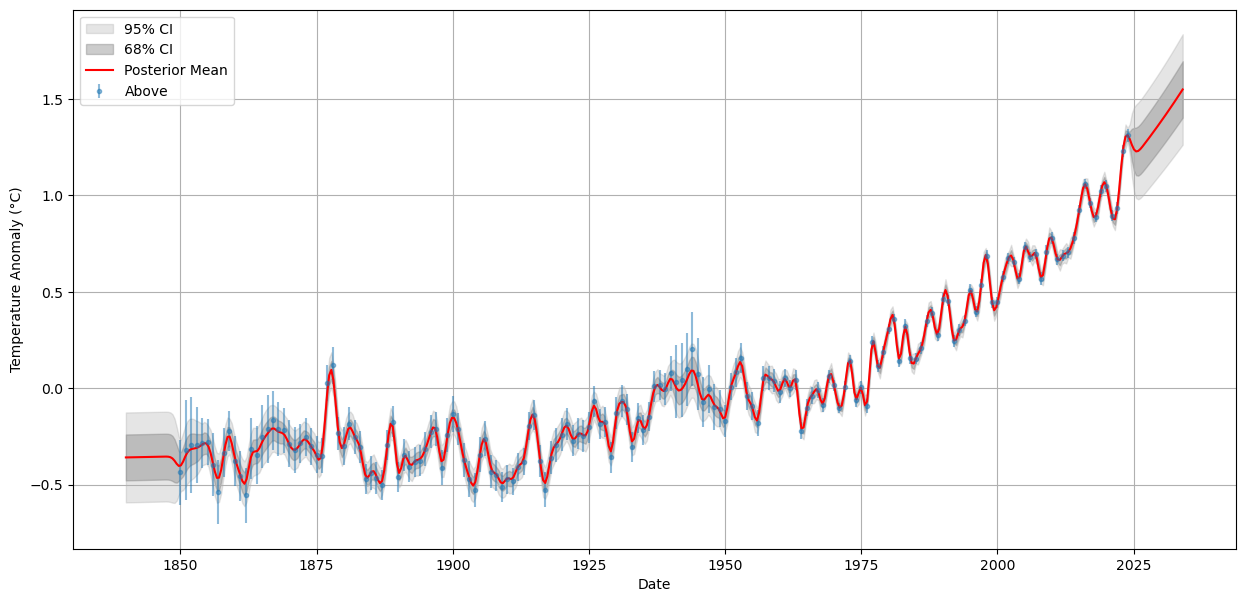

In [16]:
plt.figure(figsize=(15, 7))
plt.errorbar(df["year"], df["annual_anomaly_above"], yerr=df["annual_unc_above"], fmt="o", markersize=3, label="Above", alpha=0.5)

year_range = np.linspace(df["year"].min() - 10, df["year"].max() + 10, 500)
yerr = yerr_above.to_numpy()

# Collect predictions and variances from all posterior samples
means = []
variances = []
for params in result_exp_gp["samples"]:
    q, a, m, amp, length = params
    gp = gp_model(amplitude=amp, length_scale=length, yerr=yerr)
    trend_obs = exponential_trend(date, q, a, m)
    trend_pred = exponential_trend(year_range, q, a, m)
    mu, var = gp.predict(temp_anomaly - trend_obs, year_range.astype(float), return_var=True)
    means.append(mu + trend_pred)
    variances.append(var)

means = np.array(means)
variances = np.array(variances)

# Combine across posterior samples using law of total variance
mean_pred = np.mean(means, axis=0)
var_pred = np.mean(variances, axis=0) + np.var(means, axis=0)
std_pred = np.sqrt(var_pred)

# Plot confidence intervals
plt.fill_between(year_range, mean_pred - 1.96*std_pred, mean_pred + 1.96*std_pred, color="gray", alpha=0.2, label="95% CI")
plt.fill_between(year_range, mean_pred - 1.0*std_pred, mean_pred + 1.0*std_pred, color="gray", alpha=0.4, label="68% CI")
plt.plot(year_range, mean_pred, color="red", linewidth=1.5, label="Posterior Mean")

plt.xlabel("Date")
plt.ylabel("Temperature Anomaly (°C)")
plt.grid()
plt.legend()

plt.show()

In [17]:
def poly_trend(t, a_1, a_2, a_3):
    return a_1 * t + a_2 * t**2 + a_3 * t**3

def gp_poly_prior(cube):
    params = cube.copy()

    # q in [-50, 50]
    #params[0] = cube[0] * 100 - 50
    # a_1 in [-5.0, 5.0]
    params[0] = cube[0] * 10.0 - 5.0
    # a_2 in [-5.0, 5.0]
    params[1] = cube[1] * 10.0 - 5.0
    # a_3 in [-5.0, 5.0]
    params[2] = cube[2] * 10.0 - 5.0
    lo_4 = 1e-3
    hi_4 = 10.0
    params[3] = lo_4 + cube[3] * (hi_4 - lo_4)
    
    lo_5 = 1e-5
    hi_5 = 200.0
    params[4] = lo_5 + cube[4] * (hi_5 - lo_5)

    return params

def log_poly_gp_likelihood(params):
    a_1, a_2, a_3, amp, length = params

    if amp <= 0 or length <= 0:
        return -1e300

    trend = poly_trend(date, a_1, a_2, a_3)
    gp = gp_model(amplitude=amp, length_scale=length, yerr=yerr_above.to_numpy())
    log_likelihood_value = gp.log_likelihood(temp_anomaly - trend, quiet=True)

    if not np.isfinite(log_likelihood_value):
        return -1e300

    return log_likelihood_value

parameters_poly_gp = ["trend_a_1", "trend_a_2", "trend_a_3", "amplitude", "length_scale"]

In [18]:
sampler_poly_gp = ultranest.ReactiveNestedSampler(parameters_poly_gp, log_poly_gp_likelihood, gp_poly_prior)
result_poly_gp = sampler_poly_gp.run()

[ultranest] Sampling 400 live points from prior ...


[ultranest] Explored until L=1e+02   [134.3021..134.3022]*| it/evals=27760/341990 eff=8.1267% N=400        0   0  0   0   0  0 
[ultranest] Likelihood function evaluations: 342026
[ultranest]   logZ = 69.52 +- 0.3139
[ultranest] Effective samples strategy satisfied (ESS = 2361.6, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.06 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy wants 398 minimum live points (dlogz from 0.27 to 0.70, need <0.5)
[ultranest]   logZ error budget: single: 0.40 bs:0.31 tail:0.01 total:0.31 required:<0.50
[ultranest] done iterating.


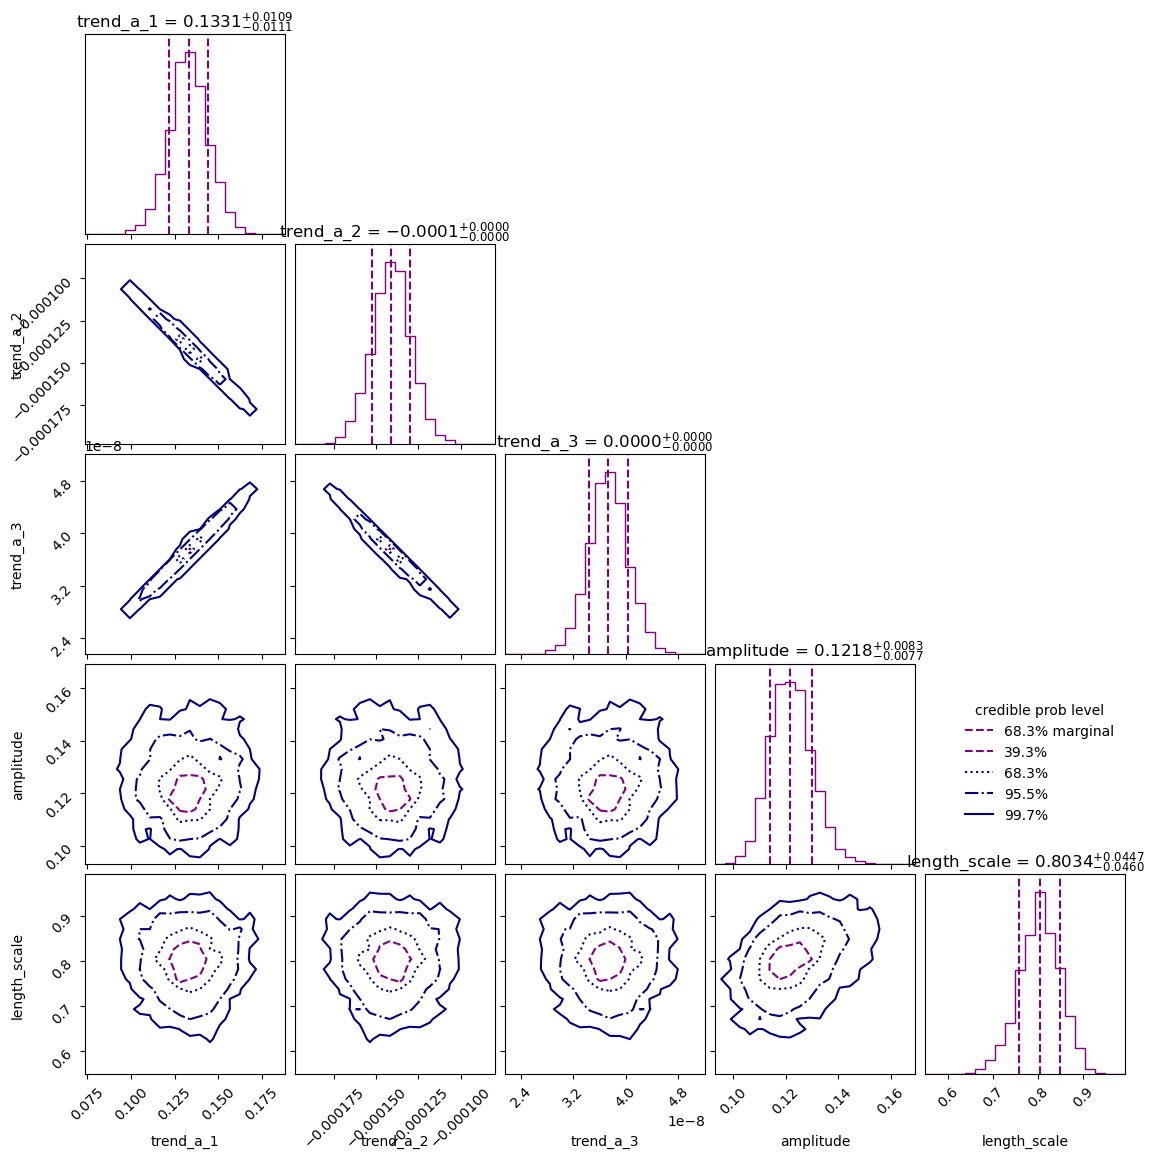

In [19]:
cornerplot(
    result_poly_gp,
    title_fmt=".4f",
    #quantiles=[0.025, 0.5, 0.975]
)
plt.show()

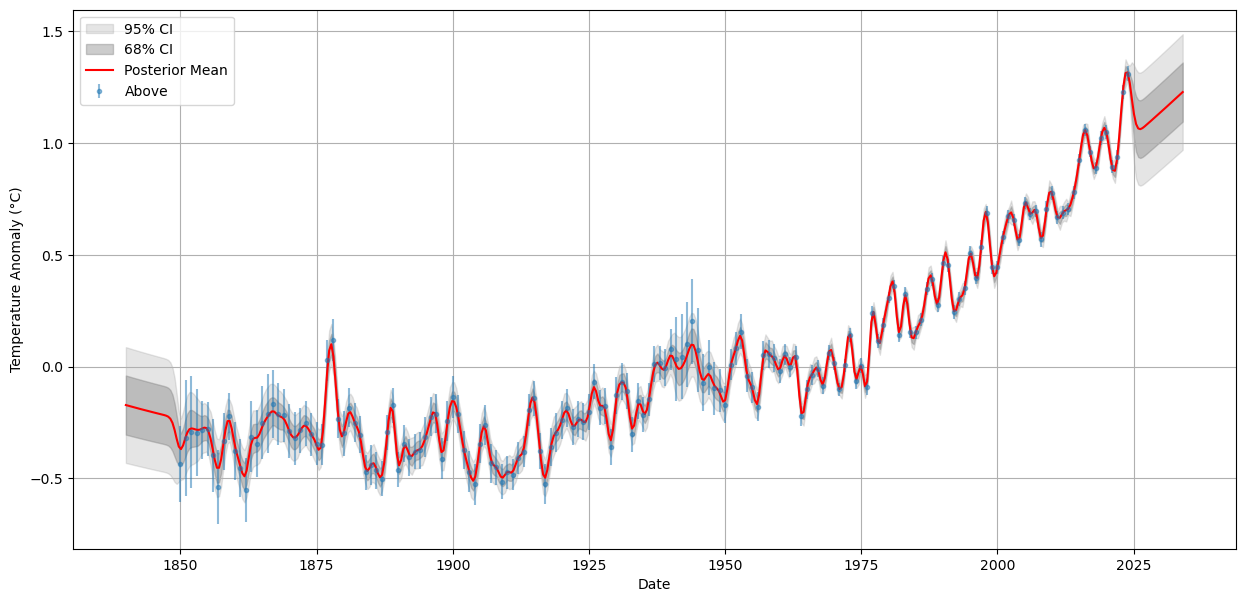

In [20]:
plt.figure(figsize=(15, 7))
plt.errorbar(df["year"], df["annual_anomaly_above"], yerr=df["annual_unc_above"], fmt="o", markersize=3, label="Above", alpha=0.5)

year_range = np.linspace(df["year"].min() - 10, df["year"].max() + 10, 500)
yerr = yerr_above.to_numpy()

# Collect predictions and variances from all posterior samples
means = []
variances = []
for params in result_poly_gp["samples"]:
    a_1, a_2, a_3, amp, length = params
    gp = gp_model(amplitude=amp, length_scale=length, yerr=yerr)
    trend_obs = poly_trend(date, a_1, a_2, a_3)
    trend_pred = poly_trend(year_range, a_1, a_2, a_3)
    mu, var = gp.predict(temp_anomaly - trend_obs, year_range.astype(float), return_var=True)
    means.append(mu + trend_pred)
    variances.append(var)

means = np.array(means)
variances = np.array(variances)

# Combine across posterior samples using law of total variance
mean_pred = np.mean(means, axis=0)
var_pred = np.mean(variances, axis=0) + np.var(means, axis=0)
std_pred = np.sqrt(var_pred)

# Plot confidence intervals
plt.fill_between(year_range, mean_pred - 1.96*std_pred, mean_pred + 1.96*std_pred, color="gray", alpha=0.2, label="95% CI")
plt.fill_between(year_range, mean_pred - 1.0*std_pred, mean_pred + 1.0*std_pred, color="gray", alpha=0.4, label="68% CI")
plt.plot(year_range, mean_pred, color="red", linewidth=1.5, label="Posterior Mean")

plt.xlabel("Date")
plt.ylabel("Temperature Anomaly (°C)")
plt.grid()
plt.legend()

plt.show()

In [21]:
out_dir = Path("results")
out_dir.mkdir(exist_ok=True)

to_save = {
    "result_gp": result_gp,
    "result_linear_gp": result_linear_gp,
    "result_exp_gp": result_exp_gp,
    "result_poly_gp": result_poly_gp
}

with open(out_dir / "gp_results.pkl", "wb") as f:
    pickle.dump(to_save, f)

# to load later:
#with open("results/gp_results.pkl", "rb") as f:
#    results = pickle.load(f)
#
#result_gp = results["result_gp"]
#result_linear_gp = results["result_linear_gp"]
#result_exp_gp = results["result_exp_gp"]

In [4]:
date_normalized = (date - date.min()) / (date.max() - date.min())

In [5]:
def exposc_trend(t, mu, alpha, beta, a1, phi1, T1):
    trend = mu + alpha * np.exp(beta * t)
    trend = mu + alpha * np.exp(beta * t)
    osc1 = a1 * np.sin(2*np.pi*t/T1 + phi1)
    return trend + osc1

def gp_exposc_prior(cube):
    theta = cube.copy()

    theta[0] = cube[0] * 4.0 - 2.0      # mu in [-2.0, 2.0]
    theta[1] = cube[1] * 5.5 - 0.5      # alpha in [-0.5, 5.0]
    theta[2] = cube[2] * 5.0            # beta in [0.0, 5.0]
    theta[3] = cube[3] * 0.5 + 0.0      # a1 in [0.0, 0.5]
    theta[4] = cube[4] * 2*np.pi        # phi1 in [0, 2*pi]
    theta[5] = cube[5] * 0.69 + 0.01    # T1 in [0.01, 0.70]
    theta[6] = cube[6] * 10.0 + 1e-5    # amp in [1e-5, 10.0]
    theta[7] = cube[7] * 20.0 + 1e-5    # length_scale in [1e-5, 20.0]
    #theta[6] = cube[6] * 0.5 + 0.0      # a2 in [0.0, 0.5]
    #theta[7] = cube[7] * 0.5 + 0.0      # b2 in [0.0, 0.5]
    #theta[8] = cube[8] * 0.20 + 0.10    # T2 in [0.10, 0.30]

    return theta

inv_sigma2 = 1.0 / sigma2

def log_gp_exposc_likelihood(theta):
    mu, alpha, beta, a1, phi1, T1, amp, length = theta

    trend = exposc_trend(date_normalized, mu, alpha, beta, a1, phi1, T1)
    gp = gp_model(amplitude=amp, length_scale=length, yerr=yerr_above.to_numpy())
    log_likelihood_value = gp.log_likelihood(temp_anomaly - trend, quiet=True)

    return log_likelihood_value

parameters_gp_exposc = ["mu", "alpha", "beta", "a1", "phi1", "T1", "amp", "length_scale"]

[ultranest] Sampling 80 live points from prior ...


[ultranest] Explored until L=1e+02  7 [146.7336..146.7360]*| it/evals=2649/465498 eff=0.5692% N=80    =80 0 
[ultranest] Likelihood function evaluations: 465498
[ultranest]   logZ = 115.1 +- 0.3897
[ultranest] Effective samples strategy wants to improve: 137.64..149.27 (ESS = 152.1, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.48+-0.15 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy wants 105 minimum live points (dlogz from 0.36 to 1.03, need <0.5)
[ultranest]   logZ error budget: single: 0.61 bs:0.39 tail:0.41 total:0.56 required:<0.50
[ultranest] Widening roots to 105 live points (have 80 already) ...
[ultranest] Sampling 25 live points from prior ...
[ultranest] Exploring (in particular: L=137.64..149.27) ...
[ultranest] Explored until L=2e+02  6 [137.6411..149.2723] | it/evals=3865/745909 eff=0.4333% N=105   5 
[ultranest] Likelihood function evaluations: 745909
[ultranest]   logZ = 115.6 +- 0.3609
[ultranest] Effective samples strategy s

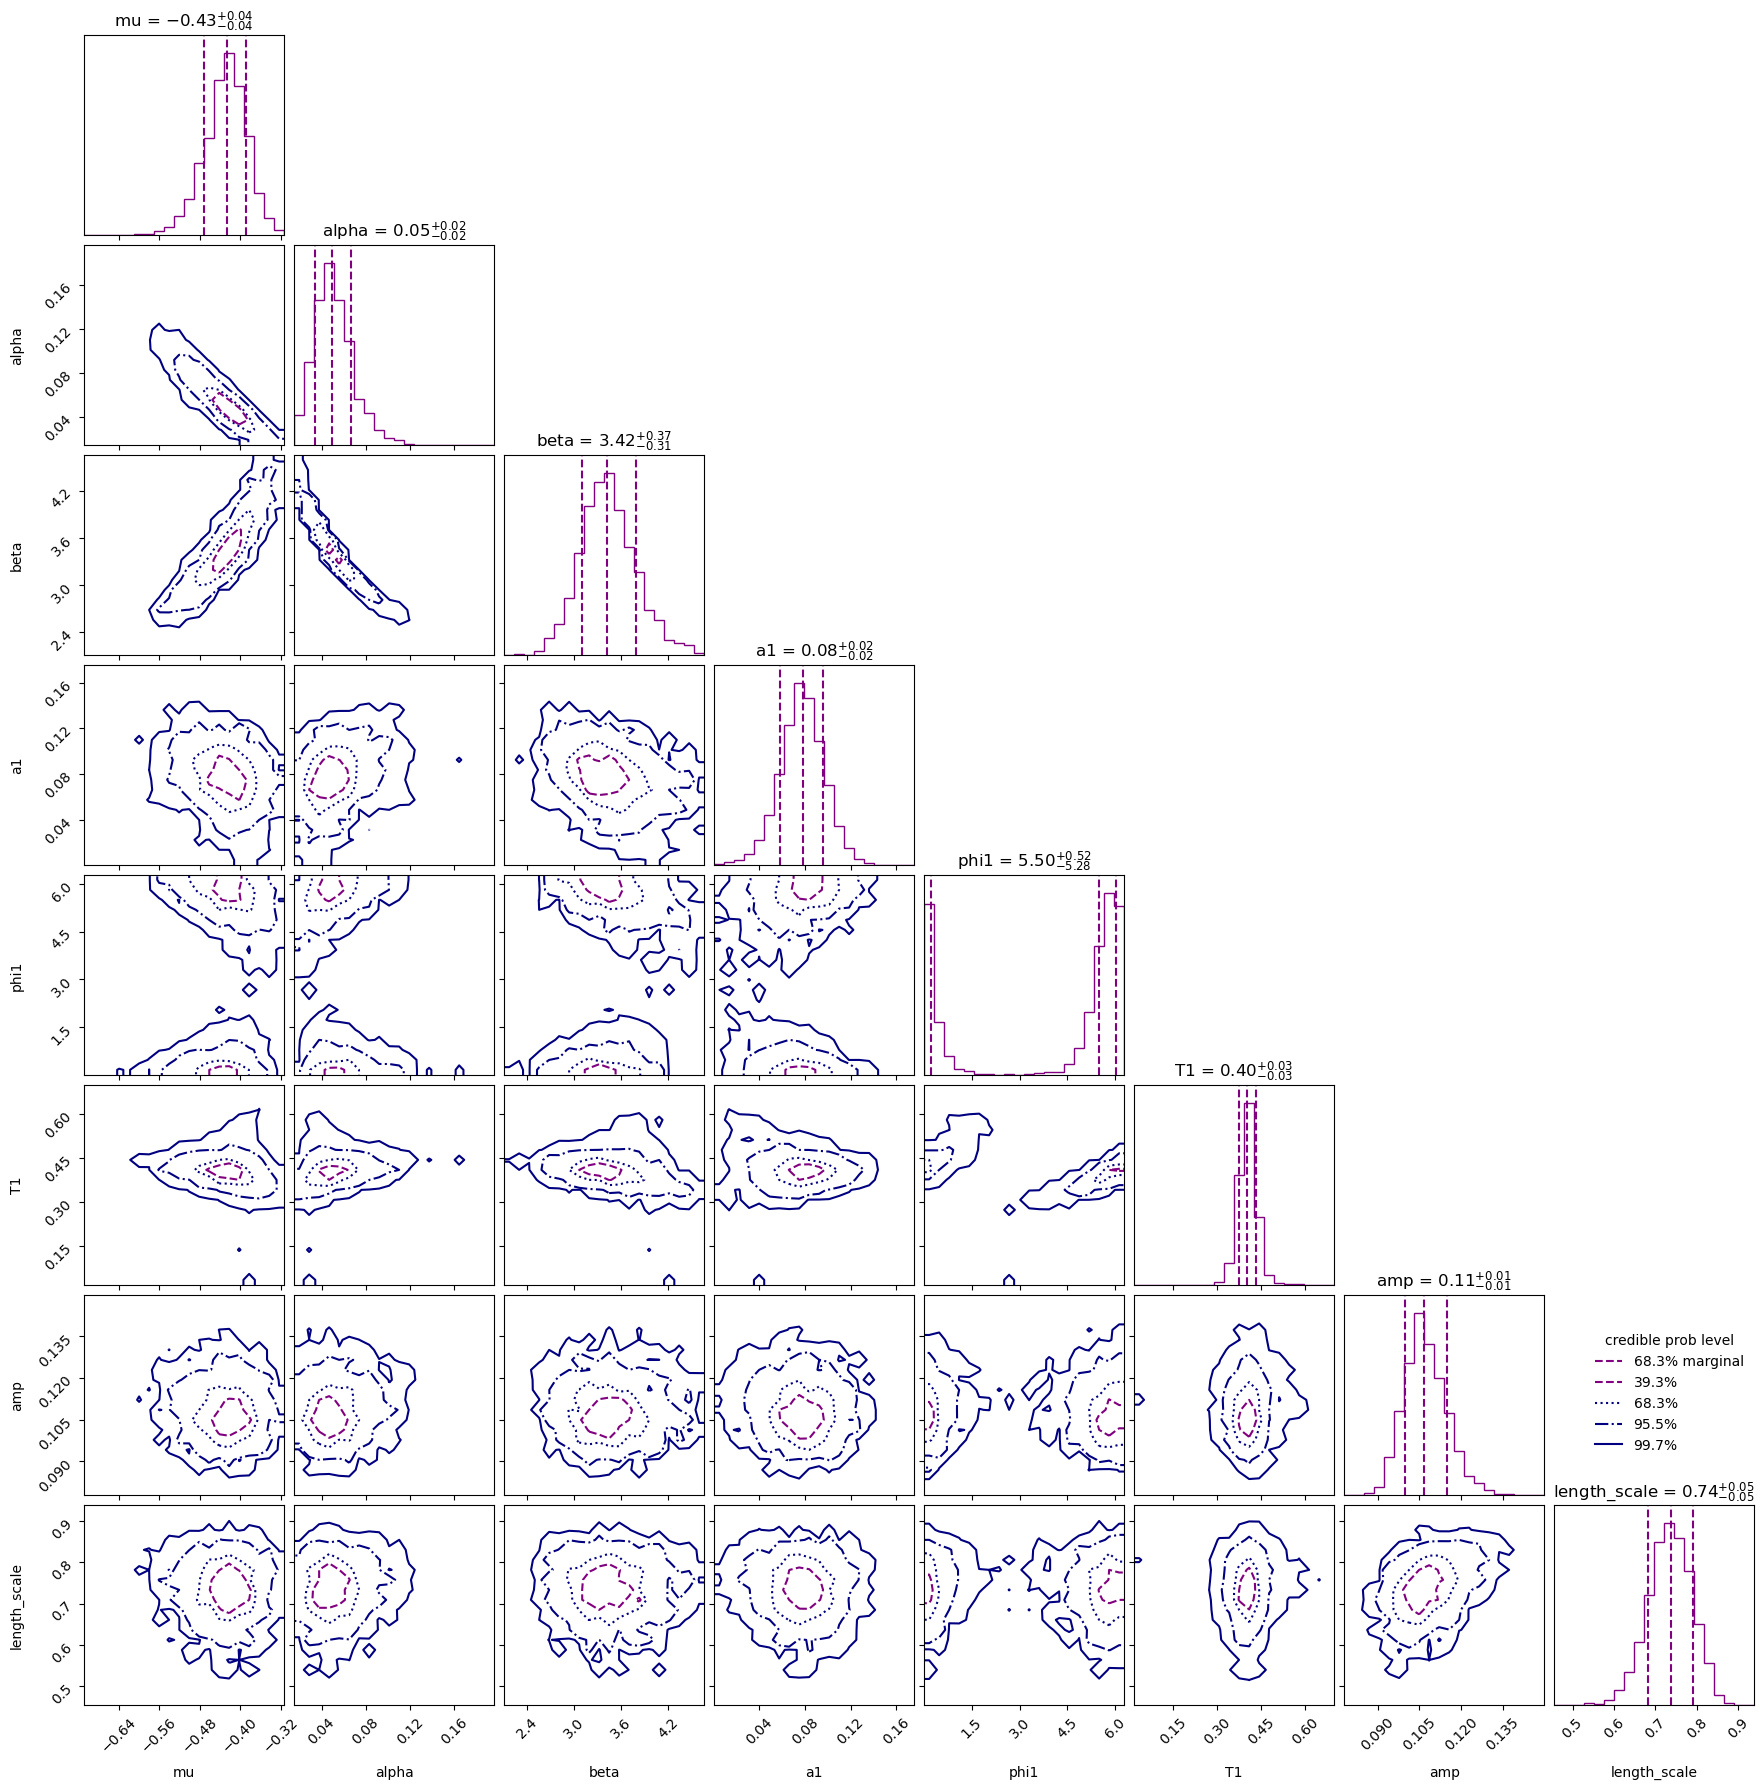

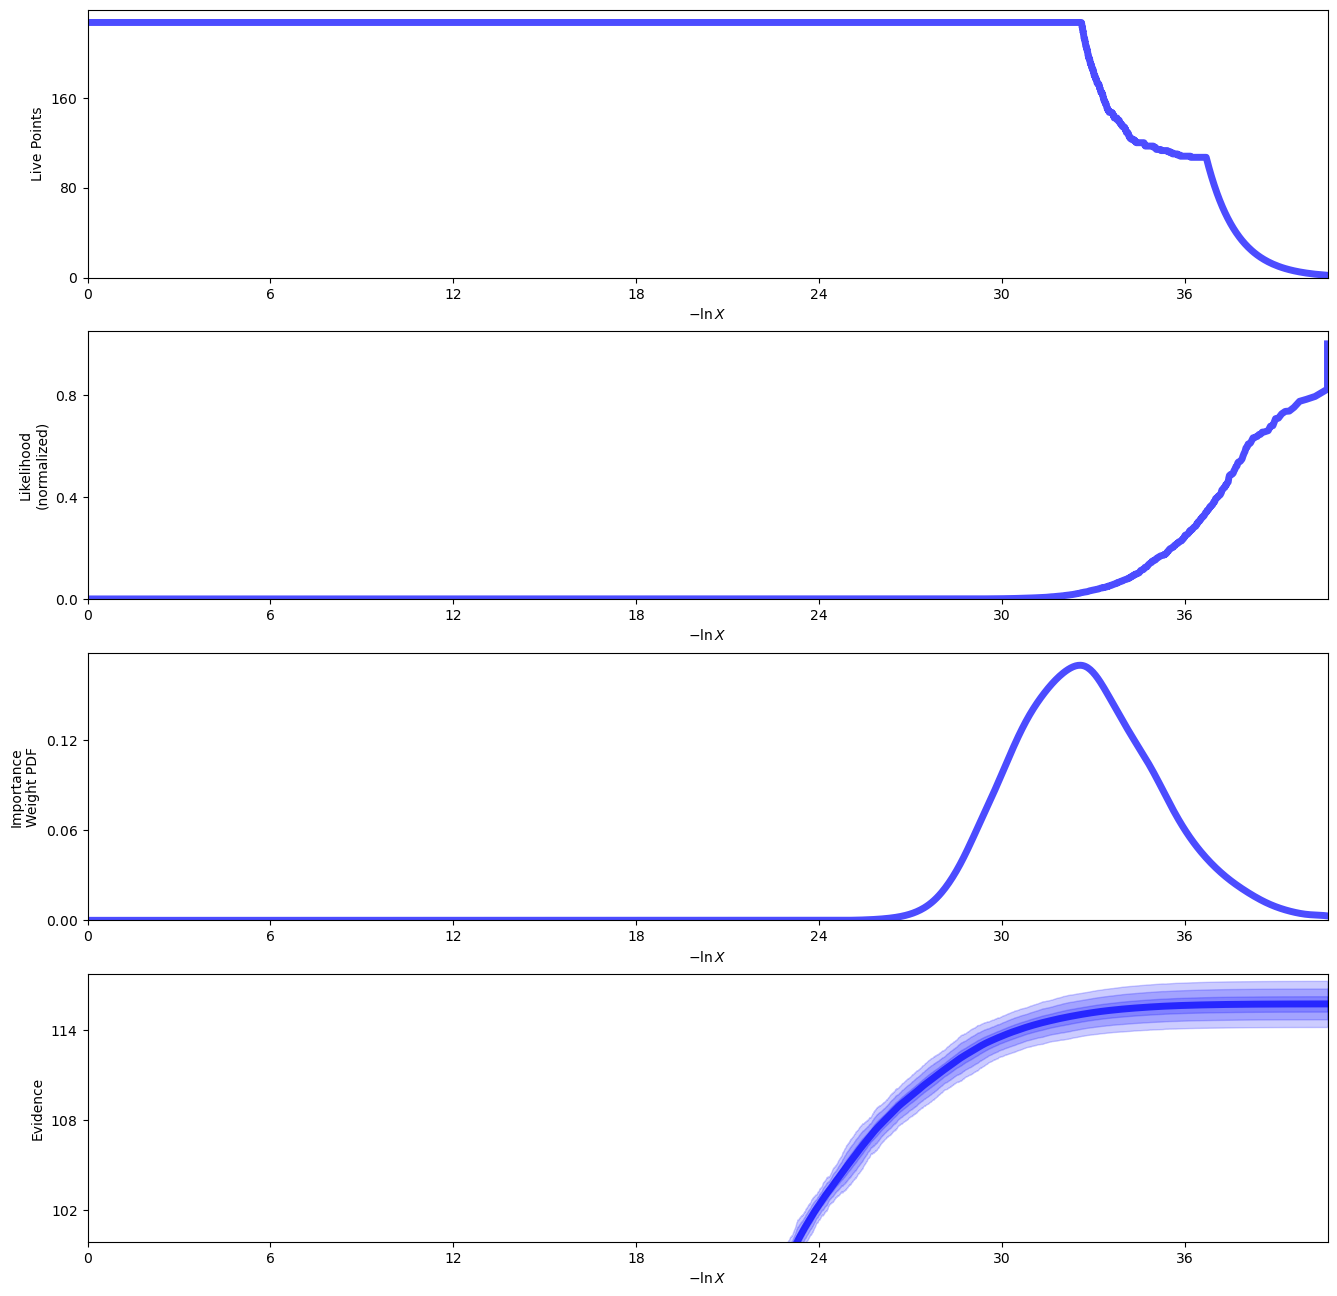

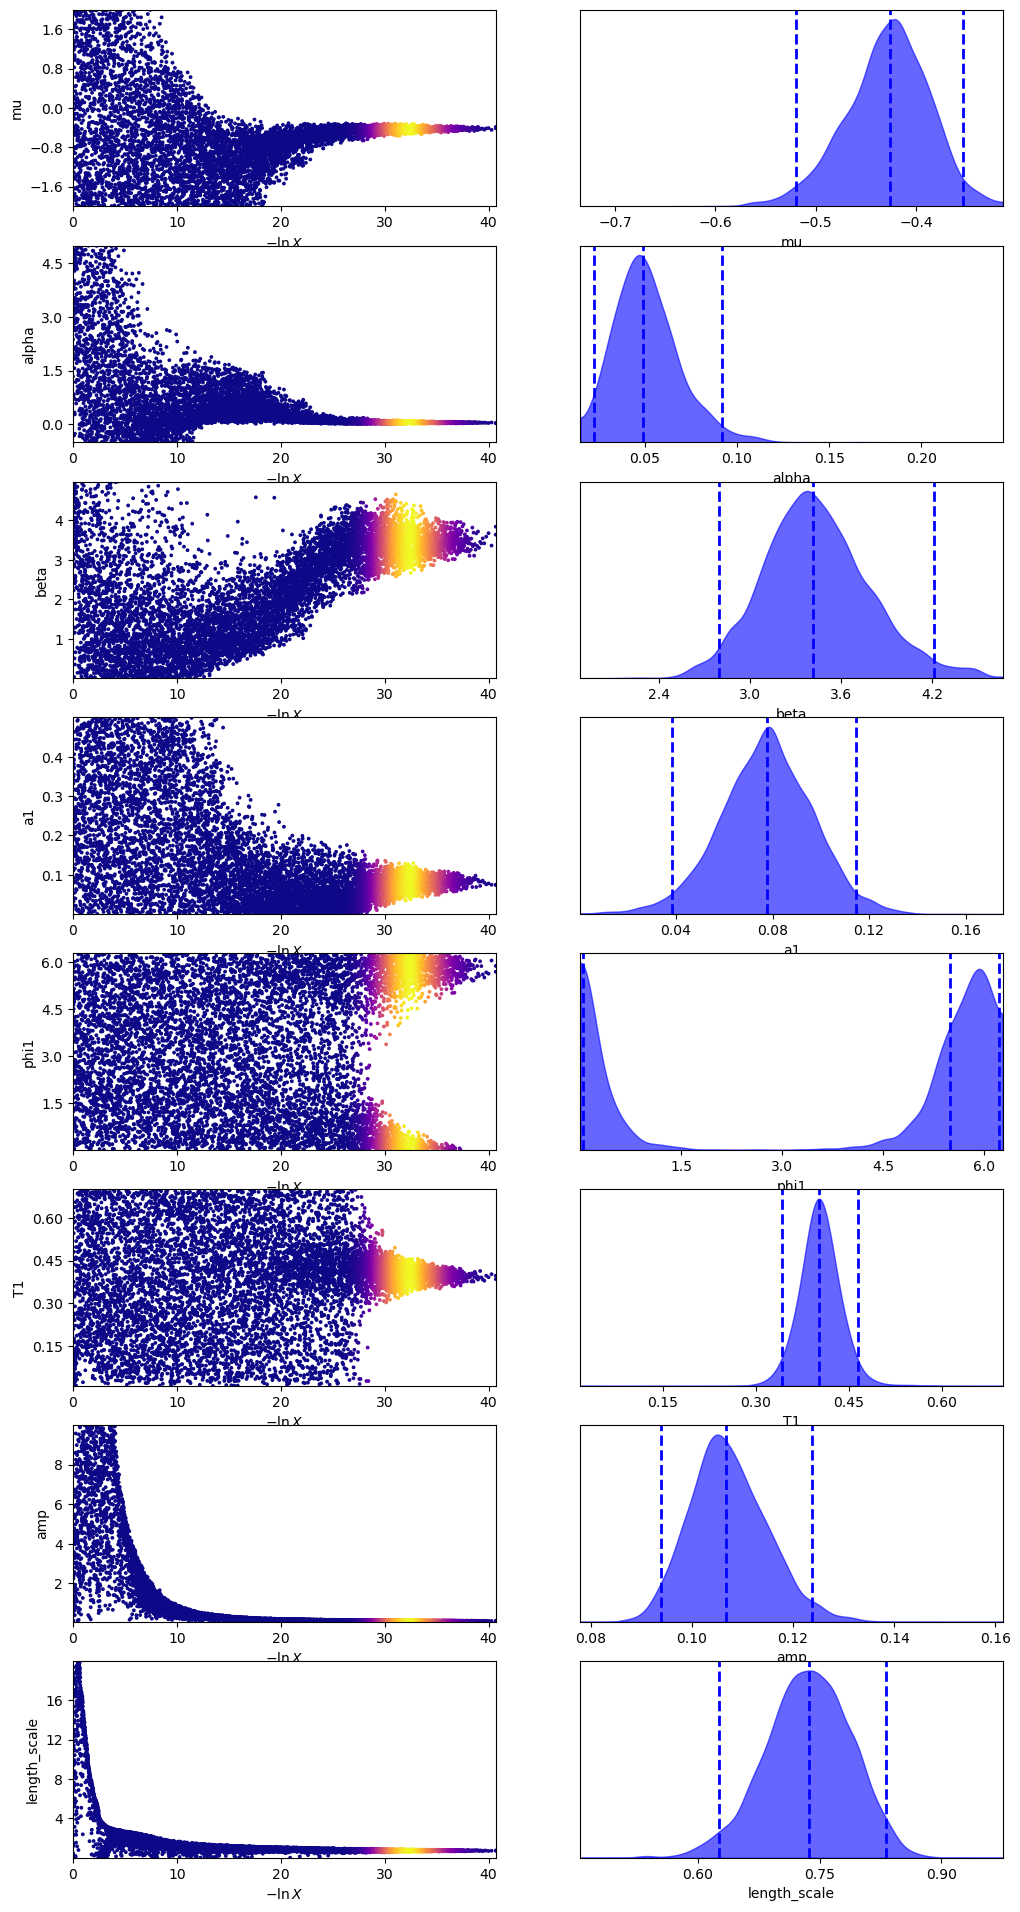

In [6]:
from ultranest.stepsampler import SliceSampler, generate_mixture_random_direction
sampler_gp_exposc = ultranest.ReactiveNestedSampler(
    parameters_gp_exposc,
    log_gp_exposc_likelihood,
    gp_exposc_prior
)

sampler_gp_exposc.stepsampler = SliceSampler(
    nsteps=10,
    adaptive_nsteps='move-distance',
    generate_direction=generate_mixture_random_direction,
    max_nsteps=80
)
result_gp_exposc = sampler_gp_exposc.run(min_num_live_points=80, frac_remain=0.5)
sampler_gp_exposc.print_results()
sampler_gp_exposc.plot()

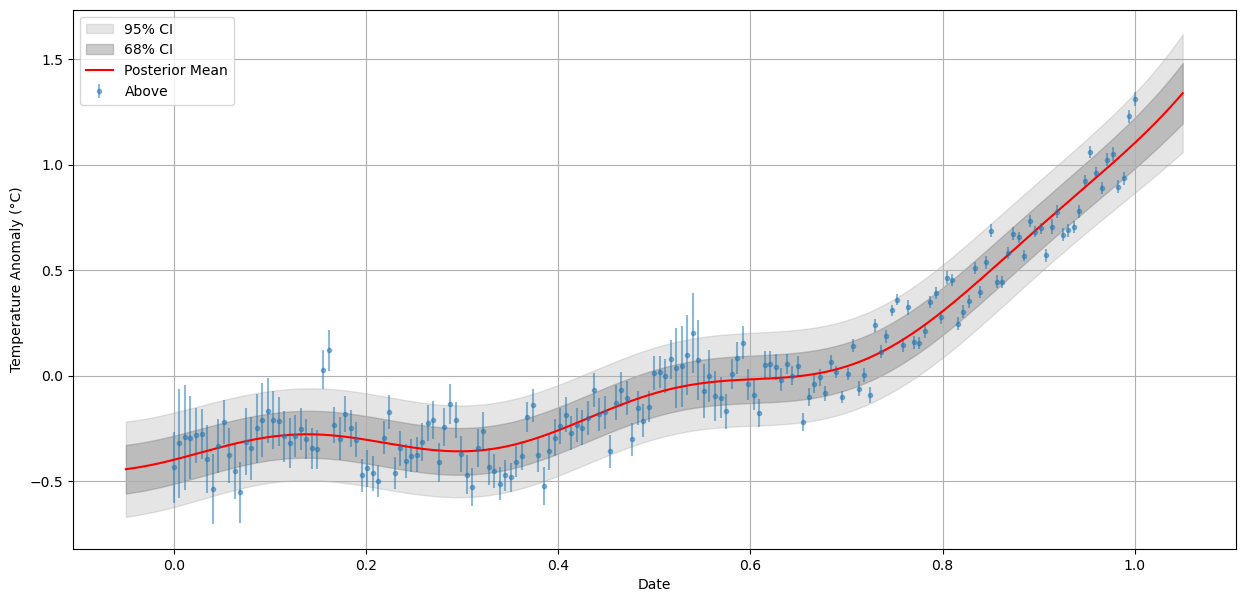

In [12]:
plt.figure(figsize=(15, 7))
plt.errorbar(date_normalized, df["annual_anomaly_above"], yerr=df["annual_unc_above"], fmt="o", markersize=3, label="Above", alpha=0.5)

year_range = np.linspace(0 - 0.05, 1.0 + 0.05, 500)
yerr = yerr_above.to_numpy()

# Collect predictions and variances from all posterior samples
means = []
variances = []
for params in result_gp_exposc["samples"]:
    mu, alpha, beta, a1, phi1, T1, amp, length = params
    gp = gp_model(amplitude=amp, length_scale=length, yerr=yerr)
    trend_obs = exposc_trend(date_normalized, mu, alpha, beta, a1, phi1, T1)
    trend_pred = exposc_trend(year_range, mu, alpha, beta, a1, phi1, T1)
    mu, var = gp.predict(temp_anomaly - trend_obs, year_range.astype(float), return_var=True)
    means.append(mu + trend_pred)
    variances.append(var)

means = np.array(means)
variances = np.array(variances)

# Combine across posterior samples using law of total variance
mean_pred = np.mean(means, axis=0)
var_pred = np.mean(variances, axis=0) + np.var(means, axis=0)
std_pred = np.sqrt(var_pred)

# Plot confidence intervals
plt.fill_between(year_range, mean_pred - 1.96*std_pred, mean_pred + 1.96*std_pred, color="gray", alpha=0.2, label="95% CI")
plt.fill_between(year_range, mean_pred - 1.0*std_pred, mean_pred + 1.0*std_pred, color="gray", alpha=0.4, label="68% CI")
plt.plot(year_range, mean_pred, color="red", linewidth=1.5, label="Posterior Mean")

plt.xlabel("Date")
plt.ylabel("Temperature Anomaly (°C)")
plt.grid()
plt.legend()

plt.show()

In [13]:
out_dir = Path("results")
out_dir.mkdir(exist_ok=True)

to_save = {
    #"result_gp": result_gp,
    #"result_linear_gp": result_linear_gp,
    #"result_exp_gp": result_exp_gp,
    "result_exposc_gp": result_gp_exposc
}

with open(out_dir / "gp_exposc_results.pkl", "wb") as f:
    pickle.dump(to_save, f)